1.Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

pd.set_option('mode.chained_assignment', None)


2.Load Raw Dataset

In [28]:
raw_data_path = 'data/raw/dirty_cafe_sales.csv'
df = pd.read_csv(raw_data_path)

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())


Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


None

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


3.Missing Values Overview

In [29]:
missing_count = df.isnull().sum()
missing_percent = 100 * missing_count / len(df)
missing_overview = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

os.makedirs('results/tables', exist_ok=True)
missing_overview.to_csv('results/tables/missing_overview_classification.csv', index=False)
display(missing_overview)


,missing_count,missing_percent
Location,3265,32.65
Payment Method,2579,25.79
Item,333,3.33
Price Per Unit,179,1.79
Total Spent,173,1.73
Transaction Date,159,1.59
Quantity,138,1.38
Transaction ID,0,0.00


4.Duplicates Check

In [30]:
# Check duplicates
dups = df.duplicated().sum()
print("Number of duplicate rows:", dups)

# Save duplicate rows to CSV
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows.to_csv('results/tables/duplicate_rows_classification.csv', index=False)

# Drop duplicates
df = df.drop_duplicates()
print("Duplicates removed. New dataset shape:", df.shape)


Number of duplicate rows: 0
Duplicates removed. New dataset shape: (10000, 8)


5.Handle Missing Values

In [31]:
# Drop rows with missing target
df = df.dropna(subset=['Payment Method'])

# Numeric columns
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_cols = ['Item', 'Location']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Transaction Date
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

display(df.head())


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


6.Outlier Removal (IQR)

In [32]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    filtered_data = data[(data[col] >= lower) & (data[col] <= upper)]
    print(f"{data.shape[0] - filtered_data.shape[0]} outliers removed from {col}")
    return filtered_data

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

df.shape


0 outliers removed from Quantity
0 outliers removed from Price Per Unit
190 outliers removed from Total Spent


(7231, 8)

7.Feature Engineering (Date)

In [33]:
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day
df['Weekday'] = df['Transaction Date'].dt.weekday
display(df.head())


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Weekday
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,8.0,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,5.0,16.0,1.0
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19,2023.0,7.0,19.0,2.0
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,2023.0,4.0,27.0,3.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,6.0,11.0,6.0


8.Encode Categorical Columns

In [34]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode target
le = LabelEncoder()
df_encoded['Payment_Method'] = le.fit_transform(df['Payment Method'])

display(df_encoded.head())


,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date,Year,Month,Day,Weekday,...,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Item_UNKNOWN,Location_In-store,Location_Takeaway,Location_UNKNOWN,Payment_Method
0,TXN_1961373,2.0,2.0,4.0,Credit Card,2023-09-08,2023.0,9.0,8.0,4.0,...,False,False,False,False,False,False,False,True,False,1
1,TXN_4977031,4.0,3.0,12.0,Cash,2023-05-16,2023.0,5.0,16.0,1.0,...,False,False,False,False,False,False,True,False,False,0
2,TXN_4271903,4.0,1.0,8.0,Credit Card,2023-07-19,2023.0,7.0,19.0,2.0,...,False,False,False,False,False,False,True,False,False,1
3,TXN_7034554,2.0,5.0,10.0,UNKNOWN,2023-04-27,2023.0,4.0,27.0,3.0,...,False,True,False,False,False,False,False,False,True,4
4,TXN_3160411,2.0,2.0,4.0,Digital Wallet,2023-06-11,2023.0,6.0,11.0,6.0,...,False,False,False,False,False,False,True,False,False,2


9.Feature Scaling

In [35]:
scaler = StandardScaler()
scale_cols = numeric_cols + ['Year','Month','Day','Weekday']
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])
display(df_encoded.head())


,Transaction ID,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date,Year,Month,Day,Weekday,...,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Item_UNKNOWN,Location_In-store,Location_Takeaway,Location_UNKNOWN,Payment_Method
0,TXN_1961373,-0.717279,-0.750648,-0.845029,Credit Card,2023-09-08,0.0,0.706444,-0.885910,0.482012,...,False,False,False,False,False,False,False,True,False,1
1,TXN_4977031,0.747875,0.067798,0.655953,Cash,2023-05-16,0.0,-0.453687,0.027075,-1.010635,...,False,False,False,False,False,False,True,False,False,0
2,TXN_4271903,0.747875,-1.569095,-0.094538,Credit Card,2023-07-19,0.0,0.126378,0.369444,-0.513086,...,False,False,False,False,False,False,True,False,False,1
3,TXN_7034554,-0.717279,1.704691,0.280708,UNKNOWN,2023-04-27,0.0,-0.743720,1.282428,-0.015537,...,False,True,False,False,False,False,False,False,True,4
4,TXN_3160411,-0.717279,-0.750648,-0.845029,Digital Wallet,2023-06-11,0.0,-0.163655,-0.543540,1.477110,...,False,False,False,False,False,False,True,False,False,2


10.Train/Test Split + SMOTE

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Drop columns that should not be used as features to avoid leakage
cols_to_drop = ['Transaction ID', 'Transaction Date', 'Payment Method']
df_clean = df_encoded.drop(columns=cols_to_drop)

# Convert all categorical columns to numbers (One-Hot Encoding)

target_col = 'Payment_Method'
features = df_clean.drop(target_col, axis=1)

# Convert non-numeric columns to numbers
X = pd.get_dummies(features, drop_first=True)

# Target column
y = df_clean[target_col]

# Handle missing values
imputer = SimpleImputer(strategy='most_frequent')  # or 'mean' for numeric columns
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Split the data into Train/Test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# Print the final shapes
print("Shapes after split and SMOTE:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)


Shapes after split and SMOTE:
X_train: (8960, 19)
X_test:  (1447, 19)
y_train: (8960,)
y_test:  (1447,)


Class Distribution After SMOTE

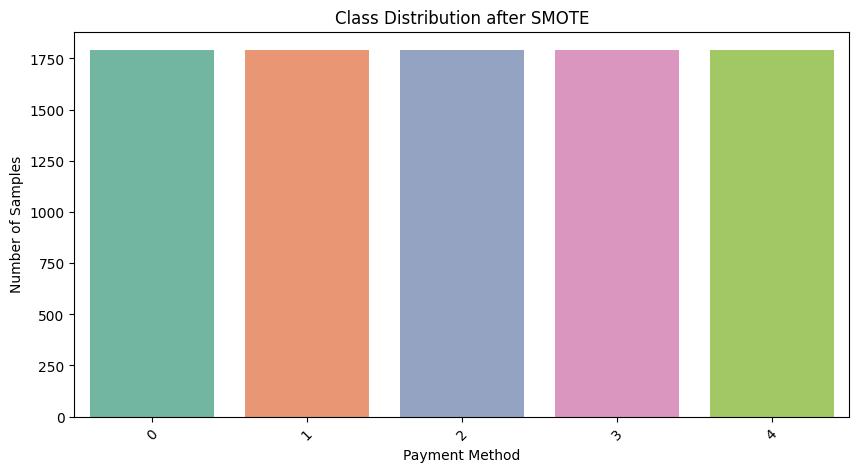

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

y_train_series = pd.Series(y_train)

plt.figure(figsize=(10,5))
sns.countplot(x=y_train_series, hue=y_train_series, palette="Set2", legend=False)
plt.title("Class Distribution after SMOTE")
plt.xlabel("Payment Method")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()


11.Save Preprocessed Data

In [38]:
os.makedirs('data/processed', exist_ok=True)
X_train.to_csv('data/processed/X_train_classification.csv', index=False)
X_test.to_csv('data/processed/X_test_classification.csv', index=False)
y_train.to_csv('data/processed/y_train_classification.csv', index=False)
y_test.to_csv('data/processed/y_test_classification.csv', index=False)

print("Preprocessed classification data saved!")


Preprocessed classification data saved!


12.Visualizations

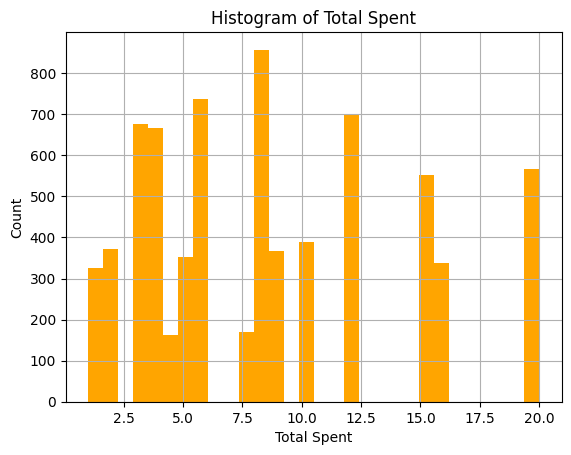

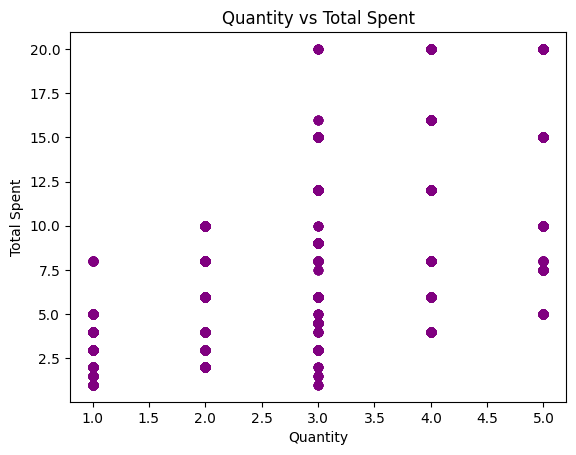

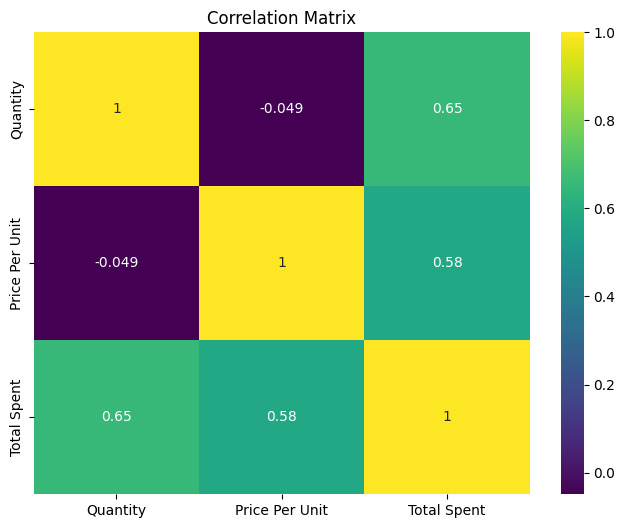

In [39]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create folders if not existing
os.makedirs("results/figures", exist_ok=True)

# Histogram
plt.figure()
df['Total Spent'].hist(bins=30, color='orange')
plt.title('Histogram of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Count')
plt.savefig('results/figures/hist_total_spent.png')
plt.show()

#  Scatter Plot
plt.figure()
plt.scatter(df['Quantity'], df['Total Spent'], alpha=0.6, color='purple')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.title('Quantity vs Total Spent')
plt.savefig('results/figures/scatter_qty_total.png')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.savefig('results/figures/corr_matrix.png')
plt.show()

